In [3]:
%pip install matplotlib pandas pillow ipympl ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [4]:
%matplotlib widget

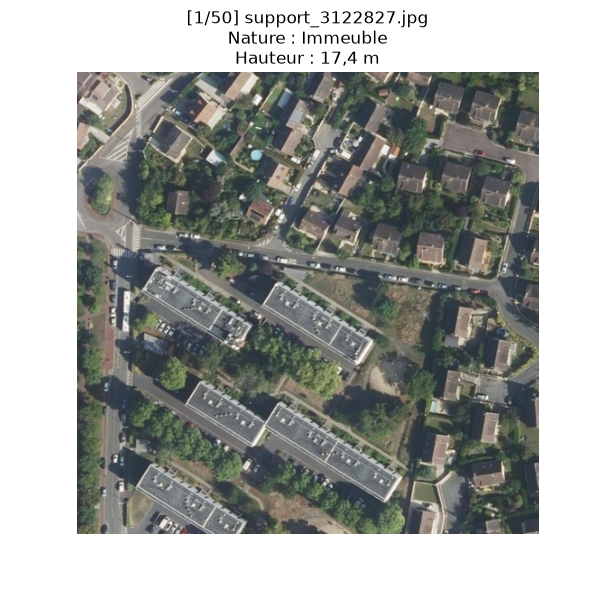

In [5]:
import os

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.widgets import RectangleSelector
from PIL import Image
from IPython.display import display, HTML


# ---------------------------------------------------------
# Paramètres
# ---------------------------------------------------------

dossier_images = "data/dataset_yolo/images/train"

dossier_labels = "data/annotations_manuelles"

chemin_resume = "data/annotations_manuelles_resume.csv"

chemin_supports = "data/supports_yvelines.csv"

chemin_natures = "data/raw/references/SUP_NATURE.txt"

nombre_images_a_annoter = 50

graine_aleatoire = 42

taille_affichage = 512


os.makedirs(
    dossier_labels,
    exist_ok=True,
)


# ---------------------------------------------------------
# Chargement des données ANFR
# ---------------------------------------------------------

supports = pd.read_csv(
    chemin_supports,
    dtype={
        "STA_NM_ANFR": str,
        "COM_CD_INSEE": str,
    },
)

supports["SUP_ID_TEXTE"] = (
    supports["SUP_ID"]
    .astype(str)
)


natures = pd.read_csv(
    chemin_natures,
    sep=";",
    header=None,
    names=[
        "NAT_ID",
        "NATURE_SUPPORT",
    ],
)

natures["NAT_ID"] = pd.to_numeric(
    natures["NAT_ID"],
    errors="coerce",
)

natures = natures.dropna(
    subset=["NAT_ID"]
)

natures["NAT_ID"] = (
    natures["NAT_ID"]
    .astype(int)
)


supports = supports.merge(
    natures,
    on="NAT_ID",
    how="left",
)


# ---------------------------------------------------------
# Recherche des images
# ---------------------------------------------------------

images_disponibles = [
    fichier
    for fichier in os.listdir(
        dossier_images
    )
    if fichier.lower().endswith(".jpg")
]


images_selectionnees = (
    pd.Series(
        images_disponibles
    )
    .sample(
        n=min(
            nombre_images_a_annoter,
            len(images_disponibles),
        ),
        random_state=graine_aleatoire,
    )
    .tolist()
)


# ---------------------------------------------------------
# Variables globales
# ---------------------------------------------------------

index_image = 0

rectangle_courant = None

resultats = []

figure = None
axe = None
selecteur = None

largeur_originale = None
hauteur_originale = None


# ---------------------------------------------------------
# Interface
# ---------------------------------------------------------

texte_statut = widgets.HTML()


bouton_sauvegarder = widgets.Button(
    description="Sauvegarder la boîte",
    button_style="success",
)


bouton_non_visible = widgets.Button(
    description="Non visible",
    button_style="danger",
)


bouton_ambigu = widgets.Button(
    description="Ambigu",
    button_style="warning",
)


bouton_passer = widgets.Button(
    description="Passer",
)


zone_boutons = widgets.HBox(
    [
        bouton_sauvegarder,
        bouton_non_visible,
        bouton_ambigu,
        bouton_passer,
    ]
)


zone_image = widgets.Output()


interface = widgets.VBox(
    [
        texte_statut,
        zone_boutons,
        zone_image,
    ]
)


display(
    interface
)


# ---------------------------------------------------------
# Sauvegarde au format YOLO
# ---------------------------------------------------------

def sauvegarder_label(
    nom_image,
    largeur_image,
    hauteur_image,
    x_min,
    y_min,
    x_max,
    y_max,
):

    centre_x = (
        (x_min + x_max)
        / 2
        / largeur_image
    )

    centre_y = (
        (y_min + y_max)
        / 2
        / hauteur_image
    )

    largeur_boite = (
        (x_max - x_min)
        / largeur_image
    )

    hauteur_boite = (
        (y_max - y_min)
        / hauteur_image
    )

    nom_label = (
        os.path.splitext(
            nom_image
        )[0]
        + ".txt"
    )

    chemin_label = os.path.join(
        dossier_labels,
        nom_label,
    )

    with open(
        chemin_label,
        "w",
        encoding="utf-8",
    ) as fichier:

        fichier.write(
            f"0 "
            f"{centre_x:.6f} "
            f"{centre_y:.6f} "
            f"{largeur_boite:.6f} "
            f"{hauteur_boite:.6f}\n"
        )


# ---------------------------------------------------------
# Sauvegarde du résumé
# ---------------------------------------------------------

def sauvegarder_resume():

    table = pd.DataFrame(
        resultats
    )

    table.to_csv(
        chemin_resume,
        index=False,
    )


# ---------------------------------------------------------
# Gestion du rectangle
# ---------------------------------------------------------

def enregistrer_rectangle(
    clic,
    relachement,
):

    global rectangle_courant

    if (
        clic.xdata is None
        or clic.ydata is None
        or relachement.xdata is None
        or relachement.ydata is None
    ):
        return

    x_min = min(
        clic.xdata,
        relachement.xdata,
    )

    y_min = min(
        clic.ydata,
        relachement.ydata,
    )

    x_max = max(
        clic.xdata,
        relachement.xdata,
    )

    y_max = max(
        clic.ydata,
        relachement.ydata,
    )

    rectangle_courant = (
        x_min,
        y_min,
        x_max,
        y_max,
    )

    texte_statut.value = (
        "<b>Boîte sélectionnée.</b><br>"
        "Cliquer sur « Sauvegarder la boîte »."
    )


# ---------------------------------------------------------
# Affichage de l'image
# ---------------------------------------------------------

def afficher_image():

    global figure
    global axe
    global selecteur
    global rectangle_courant
    global index_image
    global largeur_originale
    global hauteur_originale

    rectangle_courant = None

    # -----------------------------------------------------
    # Fin
    # -----------------------------------------------------

    if index_image >= len(
        images_selectionnees
    ):

        sauvegarder_resume()

        texte_statut.value = (
            "<h3>Annotation terminée</h3>"
            f"<p>Images traitées : "
            f"{len(resultats)}</p>"
            f"<p>Résumé : "
            f"{chemin_resume}</p>"
        )

        with zone_image:

            zone_image.clear_output(
                wait=True
            )

        return

    # -----------------------------------------------------
    # Chargement de l'image
    # -----------------------------------------------------

    nom_image = images_selectionnees[
        index_image
    ]

    chemin_image = os.path.join(
        dossier_images,
        nom_image,
    )

    image_originale = Image.open(
        chemin_image
    ).convert(
        "RGB"
    )

    largeur_originale, hauteur_originale = (
        image_originale.size
    )

    image_affichage = image_originale.resize(
        (
            taille_affichage,
            taille_affichage,
        )
    )

    # -----------------------------------------------------
    # Informations ANFR
    # -----------------------------------------------------

    sup_id = (
        nom_image
        .replace(
            "support_",
            "",
        )
        .replace(
            ".jpg",
            "",
        )
    )

    ligne_support = supports[
        supports["SUP_ID_TEXTE"]
        == str(
            sup_id
        )
    ]

    if not ligne_support.empty:

        support = ligne_support.iloc[0]

        nature_support = support[
            "NATURE_SUPPORT"
        ]

        hauteur_support = support[
            "SUP_NM_HAUT"
        ]

        longitude = support[
            "longitude"
        ]

        latitude = support[
            "latitude"
        ]

        lien_cartoradio = (
            "https://www.cartoradio.fr/"
            "#/cartographie/lonlat/"
            f"{longitude}/{latitude}"
        )

    else:

        nature_support = "Inconnue"
        hauteur_support = "Inconnue"

        longitude = None
        latitude = None

        lien_cartoradio = None

    # -----------------------------------------------------
    # Fermeture de l'ancienne figure
    # -----------------------------------------------------

    if figure is not None:

        plt.close(
            figure
        )

    # -----------------------------------------------------
    # Nouvelle figure
    # -----------------------------------------------------

    figure, axe = plt.subplots(
        figsize=(6, 6)
    )

    axe.imshow(
        image_affichage
    )

    axe.set_title(
        f"[{index_image + 1}/"
        f"{len(images_selectionnees)}] "
        f"{nom_image}\n"
        f"Nature : {nature_support}\n"
        f"Hauteur : {hauteur_support} m"
    )

    axe.axis(
        "off"
    )

    # -----------------------------------------------------
    # Sélecteur de rectangle
    # -----------------------------------------------------

    selecteur = RectangleSelector(
        axe,
        enregistrer_rectangle,
        button=[1],
        minspanx=3,
        minspany=3,
        spancoords="pixels",
        interactive=True,
    )

    # -----------------------------------------------------
    # Texte
    # -----------------------------------------------------

    texte_statut.value = (
        f"<b>Support ANFR : "
        f"{nature_support}</b><br>"
        f"Hauteur : "
        f"{hauteur_support} m<br>"
        f"Image : "
        f"{index_image + 1}/"
        f"{len(images_selectionnees)}<br><br>"
        "Dessiner une boîte avec la souris.<br>"
        "Sinon utiliser : "
        "Non visible / Ambigu / Passer."
    )

    # -----------------------------------------------------
    # Mise à jour de l'image
    # -----------------------------------------------------

    with zone_image:

        zone_image.clear_output(
            wait=True
        )

        if lien_cartoradio is not None:

            display(
                HTML(
                    f'<p>'
                    f'<a href="{lien_cartoradio}" '
                    f'target="_blank" '
                    f'style="font-size:16px; '
                    f'font-weight:bold;">'
                    f'Ouvrir cette position dans Cartoradio'
                    f'</a>'
                    f'</p>'
                )
            )

            display(
                HTML(
                    f'<p>'
                    f'Longitude : {longitude}<br>'
                    f'Latitude : {latitude}'
                    f'</p>'
                )
            )

        display(
            figure
        )


# ---------------------------------------------------------
# Action : sauvegarder la boîte
# ---------------------------------------------------------

def action_sauvegarder(
    bouton,
):

    global index_image

    if rectangle_courant is None:

        texte_statut.value = (
            "<b>Aucune boîte sélectionnée.</b><br>"
            "Dessiner d'abord une boîte."
        )

        return

    nom_image = images_selectionnees[
        index_image
    ]

    (
        x_min_affichage,
        y_min_affichage,
        x_max_affichage,
        y_max_affichage,
    ) = rectangle_courant

    # -----------------------------------------------------
    # Conversion vers les coordonnées originales
    # -----------------------------------------------------

    facteur_x = (
        largeur_originale
        / taille_affichage
    )

    facteur_y = (
        hauteur_originale
        / taille_affichage
    )

    x_min = (
        x_min_affichage
        * facteur_x
    )

    y_min = (
        y_min_affichage
        * facteur_y
    )

    x_max = (
        x_max_affichage
        * facteur_x
    )

    y_max = (
        y_max_affichage
        * facteur_y
    )

    # -----------------------------------------------------
    # Sauvegarde
    # -----------------------------------------------------

    sauvegarder_label(
        nom_image,
        largeur_originale,
        hauteur_originale,
        x_min,
        y_min,
        x_max,
        y_max,
    )

    resultats.append(
        {
            "image": nom_image,
            "statut": "annote",
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max,
        }
    )

    sauvegarder_resume()

    # -----------------------------------------------------
    # Image suivante
    # -----------------------------------------------------

    index_image += 1

    afficher_image()


# ---------------------------------------------------------
# Action générique sans boîte
# ---------------------------------------------------------

def enregistrer_statut(
    statut,
):

    global index_image

    nom_image = images_selectionnees[
        index_image
    ]

    resultats.append(
        {
            "image": nom_image,
            "statut": statut,
            "x_min": None,
            "y_min": None,
            "x_max": None,
            "y_max": None,
        }
    )

    sauvegarder_resume()

    index_image += 1

    afficher_image()


# ---------------------------------------------------------
# Boutons
# ---------------------------------------------------------

def action_non_visible(
    bouton,
):

    enregistrer_statut(
        "non_visible"
    )


def action_ambigu(
    bouton,
):

    enregistrer_statut(
        "ambigu"
    )


def action_passer(
    bouton,
):

    enregistrer_statut(
        "passee"
    )


# ---------------------------------------------------------
# Connexion des boutons
# ---------------------------------------------------------

bouton_sauvegarder.on_click(
    action_sauvegarder
)

bouton_non_visible.on_click(
    action_non_visible
)

bouton_ambigu.on_click(
    action_ambigu
)

bouton_passer.on_click(
    action_passer
)


# ---------------------------------------------------------
# Lancement
# ---------------------------------------------------------

afficher_image()

In [6]:
sauvegarder_resume()

print(
    "Résumé sauvegardé dans :",
    chemin_resume
)

Résumé sauvegardé dans : data/annotations_manuelles_resume.csv
